# How many hours can a typical client afford?

**Business question:** I charge &#36;35 an hour with a 4-hour minimum. How many hours a week can older households here afford, and how many households does each choice of rate and schedule reach?

**Why it matters:** This tests my pricing against local incomes before I commit to it. It also shows whether a different schedule, such as a visit every other week, would open the door to more clients.

**Data:** `data/census_by_zip.csv`, built by notebook 00 from the Census American Community Survey (ACS) 2020-2024.

**How to run:** Run the cells top to bottom. No Census key needed.

In [1]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)

DATA = "../data/census_by_zip.csv"
if not os.path.exists(DATA):
    raise FileNotFoundError("Run notebook 00_get_data first. It creates data/census_by_zip.csv.")
table = pd.read_csv(DATA, dtype={"zip": str}).set_index("zip")
print(table.shape[0], "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Settings you can change

**BUDGET_SHARE** is the share of yearly income I assume a household can comfortably spend on help. It is **my assumption**, and the same 12% line that notebook 04 called "comfortable". Everything below depends on it, so try 8% or 15% and run again.

In [2]:
RATE, MIN_HOURS = 35, 4
BUDGET_SHARE = 0.12

def yearly_cost(hours_per_week, rate=RATE):
    return hours_per_week * rate * 52

def income_needed(hours_per_week, rate=RATE):
    return yearly_cost(hours_per_week, rate) / BUDGET_SHARE

# Three ways a client could book me: (name, average hours per week)
PACKAGES = [("A 4-hour visit every other week", 2),
            ("A 4-hour visit every week", 4),
            ("Two 4-hour visits a week", 8)]

print(f"At ${RATE} an hour, spending up to {BUDGET_SHARE:.0%} of income:")
for name, hours in PACKAGES:
    print(f"   {name}: costs ${yearly_cost(hours):,.0f} a year, needs an income of about ${income_needed(hours):,.0f}")

At $35 an hour, spending up to 12% of income:
   A 4-hour visit every other week: costs $3,640 a year, needs an income of about $30,333
   A 4-hour visit every week: costs $7,280 a year, needs an income of about $60,667
   Two 4-hour visits a week: costs $14,560 a year, needs an income of about $121,333


## 2. Count the households above any income

The Census reports older households in income brackets, such as &#36;60,000 to &#36;74,999. To count households above an income that falls inside a bracket, this function assumes households are spread evenly within it. That makes every count below an **estimate**.

In [3]:
def bracket_start(col):
    return int(re.search(r"(\d+)k", col).group(1)) * 1000

bracket_cols = sorted([c for c in table.columns if c.startswith("hh65_income_from_")], key=bracket_start)
edges = [bracket_start(c) for c in bracket_cols]

def households_at_or_above(income, data=table):
    # Older households with at least this income, for each area
    if income > edges[-1]:
        raise ValueError(f"The top Census bracket starts at ${edges[-1]:,}; I cannot estimate above that.")
    total = 0
    for i, col in enumerate(bracket_cols):
        lo = edges[i]
        hi = edges[i + 1] if i + 1 < len(edges) else float("inf")
        if income <= lo:
            total = total + data[col]                              # whole bracket counts
        elif income < hi:
            total = total + data[col] * (hi - income) / (hi - lo)  # part of the bracket counts
    return total

# Checks: income 0 should return every household; a bracket edge should match a plain sum
all_hh = table["hh65_total"].sum()
assert abs(households_at_or_above(0).sum() - all_hh) < 1
assert abs(households_at_or_above(75000).sum() - table[[c for c in bracket_cols if bracket_start(c) >= 75000]].sum().sum()) < 1
print(f"{all_hh:,.0f} households headed by someone 65+ across all areas. Checks passed.")

64,576 households headed by someone 65+ across all areas. Checks passed.


## 3. Who can afford what

Three tests, all across the 24 areas together:

1. **Schedule:** how many older households can afford each way of booking me.
2. **Rate:** how the number changes if I charge more or less for a weekly visit.
3. **Minimum visit:** how many more households a shorter weekly visit would reach.

In [4]:
rows = []
for name, hours in PACKAGES:
    n = households_at_or_above(income_needed(hours)).sum()
    rows.append((name, yearly_cost(hours), round(income_needed(hours), -2), round(n), n / all_hh))
packages = pd.DataFrame(rows, columns=["schedule", "cost_per_year", "income_needed", "households_that_can_afford", "share_of_older_households"])

print("1. Schedule test")
for _, r in packages.iterrows():
    print(f"   {r['schedule']}: {r['share_of_older_households']:.0%} of older households (about {r['households_that_can_afford']:,.0f})")

print(f"\n2. Rate test, one {MIN_HOURS}-hour visit a week")
for rate in [30, 35, 40, 45]:
    n = households_at_or_above(income_needed(MIN_HOURS, rate)).sum()
    print(f"   ${rate} an hour: needs about ${income_needed(MIN_HOURS, rate):,.0f}; {n / all_hh:.0%} of older households (about {n:,.0f})")

print(f"\n3. Minimum-visit test at ${RATE} an hour, one visit a week")
for hours in [2, 3, 4]:
    n = households_at_or_above(income_needed(hours)).sum()
    print(f"   {hours}-hour visit: needs about ${income_needed(hours):,.0f}; {n / all_hh:.0%} of older households (about {n:,.0f})")

1. Schedule test
   A 4-hour visit every other week: 73% of older households (about 47,030)
   A 4-hour visit every week: 56% of older households (about 36,215)
   Two 4-hour visits a week: 33% of older households (about 21,518)

2. Rate test, one 4-hour visit a week
   $30 an hour: needs about $52,000; 61% of older households (about 39,110)
   $35 an hour: needs about $60,667; 56% of older households (about 36,215)
   $40 an hour: needs about $69,333; 52% of older households (about 33,552)
   $45 an hour: needs about $78,000; 48% of older households (about 31,068)

3. Minimum-visit test at $35 an hour, one visit a week
   2-hour visit: needs about $30,333; 73% of older households (about 47,030)
   3-hour visit: needs about $45,500; 64% of older households (about 41,137)
   4-hour visit: needs about $60,667; 56% of older households (about 36,215)


## 4. Hours a typical household can afford, area by area

- **hours_per_week_household**: the hours a week the typical older household in that area can afford, spending the budget share of its income.
- **hours_per_week_alone**: the same for a typical person 65+ living alone (see notebook 04 for how that income is estimated).
- **share_can_afford_weekly_visit**: the estimated share of older households in the area that can afford one 4-hour visit a week.

In [5]:
t = table[["area"]].copy()
t["older_households"] = table["hh65_total"]
t["typical_household_income"] = table["median_income_65plus_hh"]
t["hours_per_week_household"] = t["typical_household_income"] * BUDGET_SHARE / (RATE * 52)

w, m = table["median_income_women_alone_65plus"], table["median_income_men_alone_65plus"]
nw, nm = table["live_alone_women_65plus"], table["live_alone_men_65plus"]
t["typical_income_alone"] = ((w * nw + m * nm) / (nw + nm)).fillna(w).fillna(m)
t["hours_per_week_alone"] = t["typical_income_alone"] * BUDGET_SHARE / (RATE * 52)
t["share_can_afford_weekly_visit"] = households_at_or_above(income_needed(MIN_HOURS)) / table["hh65_total"]
t = t.sort_values("older_households", ascending=False)

print(f"Areas where the typical older household can afford the {MIN_HOURS}-hour weekly visit: "
      f"{(t['hours_per_week_household'] >= MIN_HOURS).sum()} of {len(t)}")
print(f"Areas where the typical person living alone can: {(t['hours_per_week_alone'] >= MIN_HOURS).sum()} of {len(t)}")
t.round(2)

Areas where the typical older household can afford the 4-hour weekly visit: 16 of 24
Areas where the typical person living alone can: 9 of 24


,area,older_households,typical_household_income,hours_per_week_household,typical_income_alone,hours_per_week_alone,share_can_afford_weekly_visit
zip,,,,,,,
94501,"Alameda, main island",6150,69740,4.60,38395.73,2.53,0.55
94611,"Oakland, Montclair / Piedmont",5760,110769,7.30,51513.50,3.40,0.67
94605,"Oakland, East Oakland hills",4153,84621,5.58,34546.37,2.28,0.65
94601,"Oakland, Fruitvale",3626,41107,2.71,18334.62,1.21,0.40
94610,"Oakland, Grand Lake",3608,102315,6.75,60094.18,3.96,0.68
94602,"Oakland, Glenview / Dimond",3602,88351,5.83,61172.04,4.03,0.64
94606,"Oakland, San Antonio / Eastlake",3089,33565,2.21,14509.00,0.96,0.30
94619,"Oakland, Laurel / Redwood Heights",2830,75556,4.98,52787.69,3.48,0.60
94612,"Oakland, downtown",2632,19241,1.27,14447.65,0.95,0.20


## 5. Chart: how many older households each schedule reaches

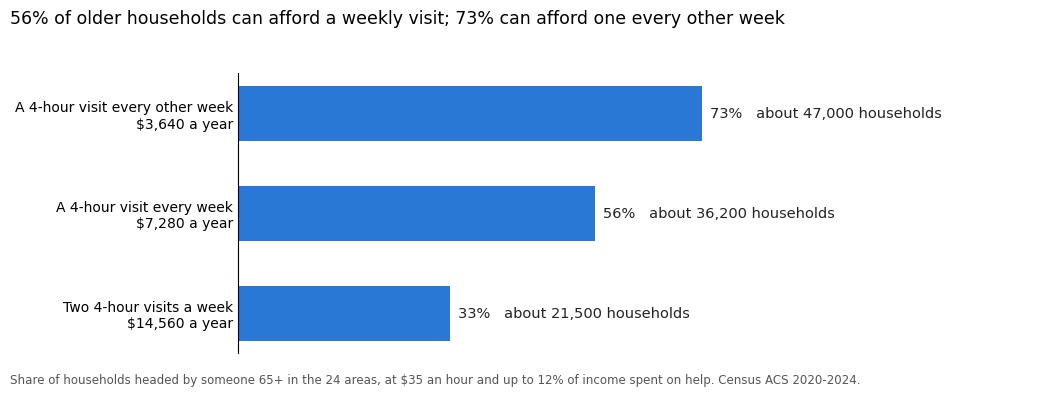

In [6]:
OUT = "../outputs"
os.makedirs(OUT, exist_ok=True)

ypos = list(range(len(packages)))[::-1]   # first row at the top
fig, ax = plt.subplots(figsize=(10.5, 3.9))
ax.barh(ypos, packages["share_of_older_households"], color="#2a78d6", height=0.55)
for y, (_, r) in zip(ypos, packages.iterrows()):
    ax.text(r["share_of_older_households"] + 0.012, y,
            f"{r['share_of_older_households']:.0%}   about {round(r['households_that_can_afford'], -2):,.0f} households",
            va="center", fontsize=10.5, color="#222222")
ax.set_yticks(ypos)
ax.set_yticklabels([f"{r['schedule']}\n\\${r['cost_per_year']:,.0f} a year" for _, r in packages.iterrows()], fontsize=10)
ax.set_xlim(0, 1.25)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
weekly = packages.loc[packages["schedule"] == "A 4-hour visit every week", "share_of_older_households"].iloc[0]
biweekly = packages.loc[packages["schedule"] == "A 4-hour visit every other week", "share_of_older_households"].iloc[0]
fig.suptitle(f"{weekly:.0%} of older households can afford a weekly visit; {biweekly:.0%} can afford one every other week",
             x=0.01, ha="left", fontsize=12.5)
fig.text(0.01, 0.02, f"Share of households headed by someone 65+ in the 24 areas, at \\${RATE} an hour and up to {BUDGET_SHARE:.0%} of income spent on help. "
         "Census ACS 2020-2024.", fontsize=8.5, color="#555555")
plt.tight_layout(rect=(0, 0.06, 1, 0.94))
fig.savefig(f"{OUT}/affordable_hours.png", dpi=150)
packages.round(3).to_csv(f"{OUT}/affordable_schedules.csv", index=False)
t.round(3).to_csv(f"{OUT}/affordable_hours_by_area.csv")
plt.show()

## 6. What I decided

- **Keep the &#36;35 rate?** Yes. Moving the rate by &#36;5 changes the households I can reach by only about 4 percentage points.
- **Keep the 4-hour minimum?** Yes.
- **Offer an every-other-week schedule?** Yes. It reaches about 73% of older households instead of 56%, and I keep the 4-hour visit.

### Limits to remember
- The budget share is my assumption. A household with savings, long-term care insurance or family help can spend more than its income suggests.
- These counts are all older households, whether or not they need or want help. They show who could afford me, not who will hire me.
- Counts inside an income bracket assume households are spread evenly within it, so they are estimates.
- Household income overstates what people living alone can afford; notebook 04 covers them.